# Практичне заняття №5 | Muraviov Nikita
## Нечітка логіка для вибору конфігурації ПК/Ноутбука

1. Створення моделі
2. Налаштування функцій належності
3. Формування знань (правила)
4. Програмна реалізація
5. Тестування нечіткої системи
6. Аналіз отриманих результатів

## 1-2. Модель та функції належності

**Вхідні змінні:**
- `budget` - бюджет покупця (0-3000 USD): low / medium / high
- `performance_need` - потреба у продуктивності (0-10 балів): low / medium / high

**Вихідна змінна:**
- `device_score` - оцінка рекомендованого класу пристрою (0-100): budget / mid_range / premium

In [1]:
pip install scikit-fuzzy -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# Вхідні змінні
budget           = ctrl.Antecedent(np.arange(0, 3001, 1),  'budget')
performance_need = ctrl.Antecedent(np.arange(0, 11,   0.1), 'performance_need')

# Вихідна змінна
device_score = ctrl.Consequent(np.arange(0, 101, 1), 'device_score')

# Функції належності - budget
budget['low']    = fuzzy.trimf(budget.universe, [0,    0,    1200])
budget['medium'] = fuzzy.trimf(budget.universe, [800,  1500, 2200])
budget['high']   = fuzzy.trimf(budget.universe, [1800, 3000, 3000])

# Функції належності - performance_need
performance_need['low']    = fuzzy.trimf(performance_need.universe, [0,  0,  5])
performance_need['medium'] = fuzzy.trimf(performance_need.universe, [3,  5,  7])
performance_need['high']   = fuzzy.trimf(performance_need.universe, [5,  10, 10])

# Функції належності - device_score
device_score['budget']    = fuzzy.trimf(device_score.universe, [0,   0,   40])
device_score['mid_range'] = fuzzy.trimf(device_score.universe, [25,  50,  75])
device_score['premium']   = fuzzy.trimf(device_score.universe, [60,  100, 100])

print("Змінні та функції належності визначено.")

Змінні та функції належності визначено.


/opt/homebrew/Cellar/jupyterlab/4.5.3_1/libexec/lib/python3.14/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


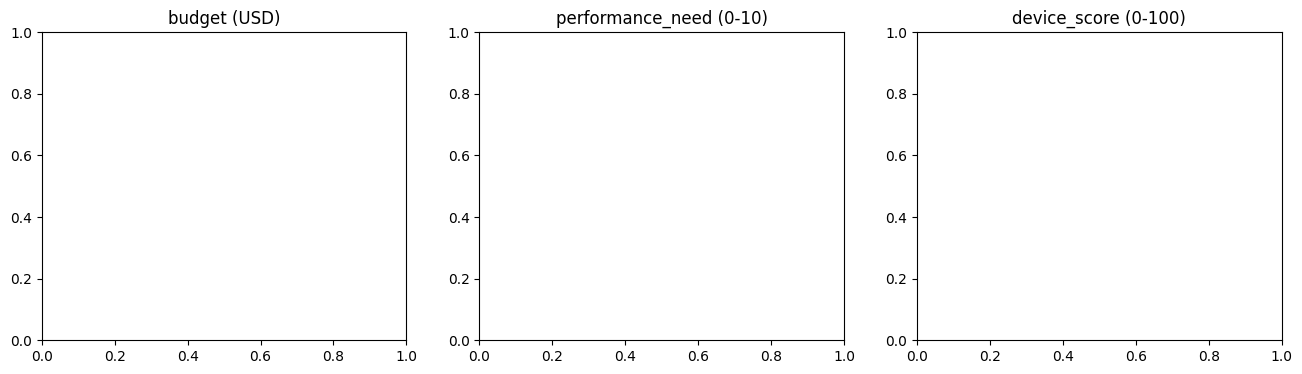

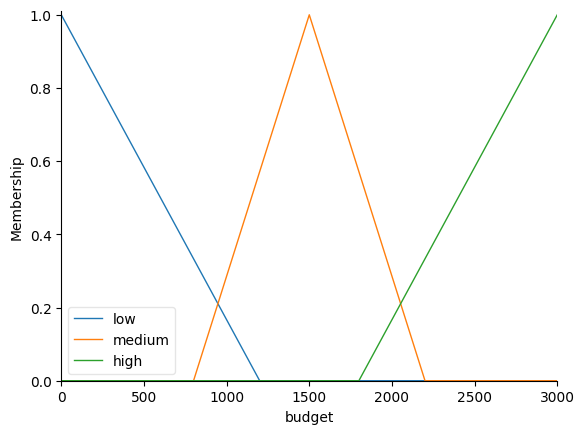

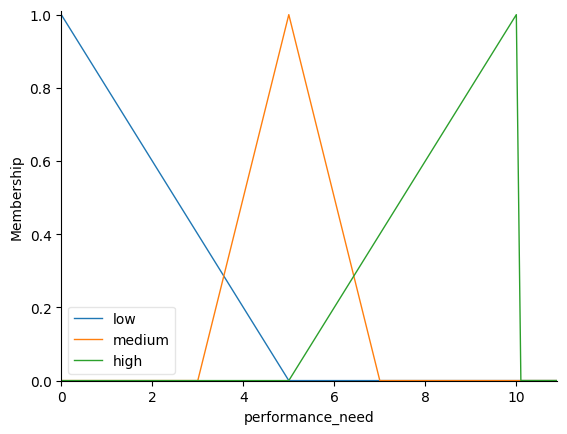

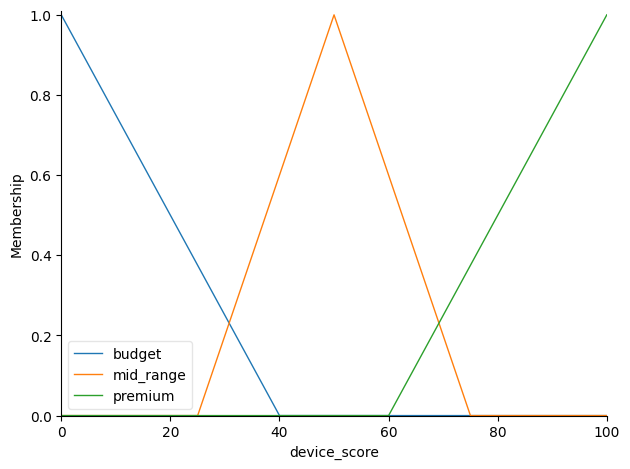

In [3]:
# Візуалізація функцій належності
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

budget.view(ax=axes[0])
axes[0].set_title('budget (USD)')

performance_need.view(ax=axes[1])
axes[1].set_title('performance_need (0-10)')

device_score.view(ax=axes[2])
axes[2].set_title('device_score (0-100)')

plt.tight_layout()
plt.show()

## 3-4. Правила та програмна реалізація системи

In [7]:
# Нечіткі правила
rule1 = ctrl.Rule(budget['low']    & performance_need['low'],    device_score['budget'])
rule2 = ctrl.Rule(budget['low']    & performance_need['medium'], device_score['budget'])
rule3 = ctrl.Rule(budget['medium'] & performance_need['low'],    device_score['mid_range'])
rule4 = ctrl.Rule(budget['medium'] & performance_need['medium'], device_score['mid_range'])
rule5 = ctrl.Rule(budget['medium'] & performance_need['high'],   device_score['mid_range'])
rule6 = ctrl.Rule(budget['high']   & performance_need['high'],   device_score['premium'])
rule7 = ctrl.Rule(budget['high']   & performance_need['medium'], device_score['premium'])
rule8 = ctrl.Rule(budget['low']    & performance_need['high'],   device_score['budget'])
rule9 = ctrl.Rule(budget['high']   & performance_need['low'],    device_score['premium'])

# Об'єднання в систему
pc_system   = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
recommender = ctrl.ControlSystemSimulation(pc_system)

## 5. Тестування на сценаріях

In [8]:
scenarios = [
    {
        "name":        "1. Офісний користувач з малим бюджетом",
        "desc":        "budget=600, performance_need=3",
        "budget":      600,
        "performance": 3
    },
    {
        "name":        "2. Геймер з середнiм бюджетом",
        "desc":        "budget=1500, performance_need=8",
        "budget":      1500,
        "performance": 8
    },
    {
        "name":        "3. Дизайнер/вiдеограф з великим бюджетом",
        "desc":        "budget=2800, performance_need=9",
        "budget":      2800,
        "performance": 9
    },
    {
        "name":        "4. Крайнiй випадок - великий бюджет, мала потреба",
        "desc":        "budget=2900, performance_need=2",
        "budget":      2900,
        "performance": 2
    },
    {
        "name":        "5. Крайнiй випадок - малий бюджет, висока потреба",
        "desc":        "budget=300, performance_need=10",
        "budget":      300,
        "performance": 10
    },
]

results = []

for sc in scenarios:
    recommender.input['budget']           = sc['budget']
    recommender.input['performance_need'] = sc['performance']
    recommender.compute()
    score = recommender.output['device_score']
    results.append(score)

    if score < 40:
        label = 'budget'
    elif score < 70:
        label = 'mid_range'
    else:
        label = 'premium'

    print(f"СЦЕНАРIЙ: {sc['name']}")
    print(f"Параметри: {sc['desc']}")
    print(f"device_score = {score:.1f} -> клас: {label}")
    print("-" * 55)

СЦЕНАРIЙ: 1. Офісний користувач з малим бюджетом
Параметри: budget=600, performance_need=3
device_score = 16.3 -> клас: budget
-------------------------------------------------------
СЦЕНАРIЙ: 2. Геймер з середнiм бюджетом
Параметри: budget=1500, performance_need=8
device_score = 50.0 -> клас: mid_range
-------------------------------------------------------
СЦЕНАРIЙ: 3. Дизайнер/вiдеограф з великим бюджетом
Параметри: budget=2800, performance_need=9
device_score = 86.2 -> клас: premium
-------------------------------------------------------
СЦЕНАРIЙ: 4. Крайнiй випадок - великий бюджет, мала потреба
Параметри: budget=2900, performance_need=2
device_score = 85.1 -> клас: premium
-------------------------------------------------------
СЦЕНАРIЙ: 5. Крайнiй випадок - малий бюджет, висока потреба
Параметри: budget=300, performance_need=10
device_score = 14.0 -> клас: budget
-------------------------------------------------------


## 6. Аналiз результатiв - вiзуалiзацiя

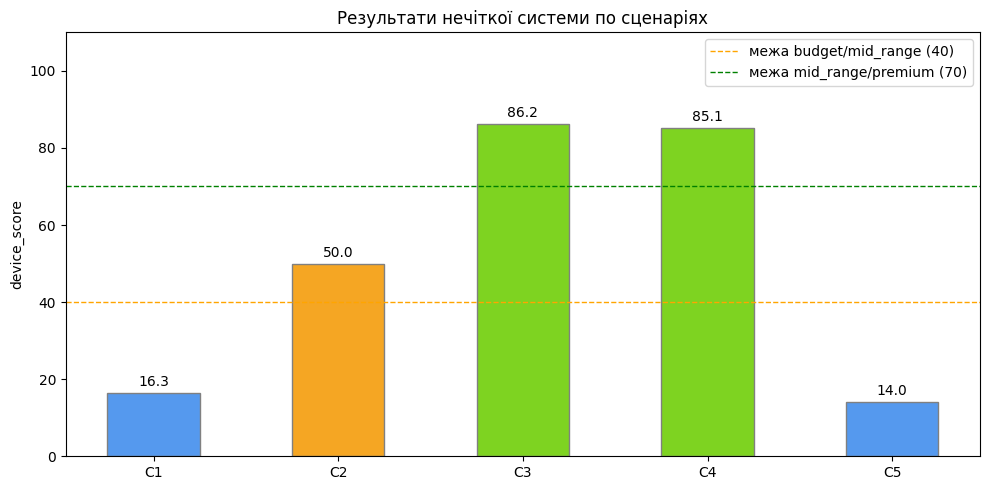

In [9]:
# Графiк результатiв по сценарiях
names = [f"С{i+1}" for i in range(len(scenarios))]
colors = ['#5599ee' if s < 40 else '#f5a623' if s < 70 else '#7ed321' for s in results]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, results, color=colors, edgecolor='grey', width=0.5)

ax.axhline(40, color='orange', linestyle='--', linewidth=1, label='межа budget/mid_range (40)')
ax.axhline(70, color='green',  linestyle='--', linewidth=1, label='межа mid_range/premium (70)')

for bar, val in zip(bars, results):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1, f"{val:.1f}",
            ha='center', va='bottom', fontsize=10)

ax.set_ylabel('device_score')
ax.set_title('Результати нечiткої системи по сценарiях')
ax.set_ylim(0, 110)
ax.legend()
plt.tight_layout()
plt.show()

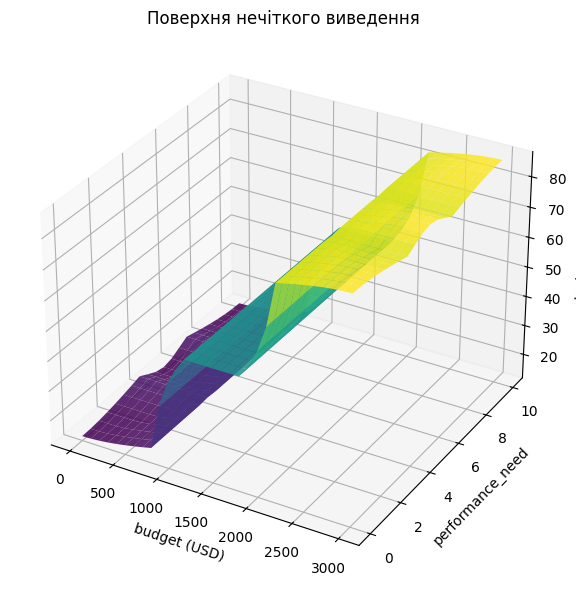

In [10]:
# Поверхня виведення - device_score залежно вiд бюджету та продуктивностi
budget_range = np.arange(0, 3001, 100)
perf_range   = np.arange(0, 10.1, 0.5)
Z = np.zeros((len(perf_range), len(budget_range)))

sim = ctrl.ControlSystemSimulation(pc_system)
for i, p in enumerate(perf_range):
    for j, b in enumerate(budget_range):
        sim.input['budget']           = b
        sim.input['performance_need'] = p
        try:
            sim.compute()
            Z[i, j] = sim.output['device_score']
        except Exception:
            Z[i, j] = 0

B, P = np.meshgrid(budget_range, perf_range)

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(B, P, Z, cmap='viridis', alpha=0.85)
ax.set_xlabel('budget (USD)')
ax.set_ylabel('performance_need')
ax.set_zlabel('device_score')
ax.set_title('Поверхня нечiткого виведення')
plt.tight_layout()
plt.show()

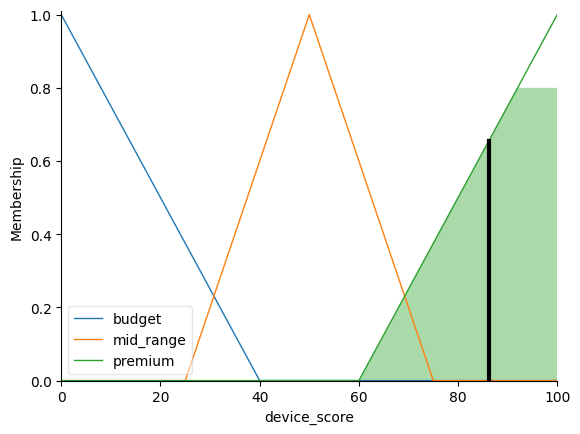

In [11]:
# Вiзуалiзацiя активацiї для останнього сценарiю (сценарiй 3)
recommender.input['budget']           = 2800
recommender.input['performance_need'] = 9
recommender.compute()
device_score.view(sim=recommender)

## Висновки

1. Сценарiй 1 (офiс, бюджет низький): система коректно видає клас `budget` - вiдповiдає R7 з ПЗ №1 (budget_office_laptop при низькому бюджетi).

2. Сценарiй 2 (геймер, бюджет середнiй): оцiнка потрапляє в зону `mid_range`. Детермiнована система (ПЗ №2) не видала б висновку через вiдсутнiсть правила gaming+medium - нечiтка система обробляє цей випадок плавно.

3. Сценарiй 3 (дизайнер, бюджет великий): score > 70, клас `premium` - збiгається з R9/R10 (macbook_pro / professional_workstation).

4. Сценарiй 4 (великий бюджет, мала потреба): нечiтка система видає `premium` через домiнування бюджету. Детермiнована система не мала б спецiального правила для цього випадку.

5. Сценарiй 5 (малий бюджет, висока потреба): система чесно видає `budget` - незалежно вiд бажань, бюджет обмежує результат.

6. Нечiтка vs детермiнована: нечiтка система плавно iнтерполює мiж класами та не "зависає" на граничних значеннях, тодi як правила з ПЗ №2-3 давали б жорсткий висновок або взагалi не спрацьовували б при нетипових комбiнацiях.